# Part 2 Challenges

# Challenge 2.1

## Objective

Create a script that will take a user input, find the factors of that number, and print those factors.

## Hints

- Probably you know already what the factors of a number are, but [here you go](https://www.mathsisfun.com/numbers/factors-all-tool.html)
- Use a list to store the factors you have found
- Use a loop to check each possible factor
- Use the function `input()` to collect a user's input
- That input is going to be a string, turn it into an integer

## Solution

Write below your solution.
Here is the possible output of a script solving this challenge:

What number would you like to find the factors of?
`12`<br>
The factors of 12 are: [1, 2, 3, 4, 6, 12]

In [ ]:
def find_factors(number):
    # Functions because why not?

    # Initialize out list
    factors = []

    # Starting from 1, let's test each number
    for curr in range(1, number + 1):
        # Taking the modulas, if there is a reminder,
        #  It's not a factor
        if (number % curr == 0):
            # We found a factor, add it to our list
            factors.append(curr)

    # We went through every number from 1 to the user's number
    # Return what we have
    return factors

# Ask the user for an input (and take the integer of the string that comes in)
usr_inp = int(input("What number would you like to find the factors of? "))
# Print out the factors
print("The factors of", usr_inp, "are:", find_factors(usr_inp))


# Challenge 2.2

## Objective

Create a script that can generate a fraction consisting of 10 unique digits on the numerator and 10 unique digits on the denominator that can be a close approximation of PI. So, each number (1,2,3,4,5,6,7,9,0) can and must only be used once in the numerator and once in the denominator. I.e. both numerator and denominator are a shuffle of "1234567890".

## Hints

- You will probably use random numbers (`import random`) for either the denominator or the numerator
- Use a list for creating the random unique numbers
- Also, add the math module, it contains PI `math.pi` (`import math`)
- You will probably use loops
- This is simpler than you think

## Solution

Write below your solution.
This is one of the many answers that could be generated through a good script:

The numerator is: 2385140697<br>
The denominator is: 0759213864<br>
The approximation of PI is: 3.141592652739018

In [ ]:
from random import shuffle
from math import pi


def pi_finder():
    # Keeping trying until we find a suitable denominator and numerator
    while(1):
        # First: Take 9 digits, randomize the order, & create a number from it
        denominator_list = ["1","2","3","4","5","6","7","8","9"]
        shuffle(denominator_list)

        # Multiple ways to do this, this take a list of numbers, and takes an
        #  empty string and adds each element from the list - finally taking the
        #  numeric value of the string using int()
        denominator = int(''.join(denominator_list))


        # Second: Take that number times PI (denominator times pi equal numerator)
        #         and then take the integer of the value
        numerator = denominator * pi
        numerator = int(numerator)

        # Third: Check if it's 9 digits, and check if those digits are unique
        #        from each other
        # Much easier to deal with strings at this point
        str_numerator = str(numerator)

        if (len(str_numerator) != 9):
            # Continue means reset from the top of the loop
            continue

        # Create a pool and remove each number as it is found
        pool = ["1","2","3","4","5","6","7","8","9"]

        for curr in list(str_numerator):
            # Take each number out as it is found
            if (curr in pool):
                pool.remove(curr)

        if (pool != []):
            # If it is not empty, there are dups in the numerator
            continue

        # At this point all checks have passed, return the number
        return [numerator, denominator]


# Run the function
result = pi_finder()

# Print out the results
print("The numerator is:", result[0])
print("The denominator is:", result[1])
print("The approximation of PI is:", result[0]/result[1])

# Challenge 2.3

## Objective

We have been given some file transfer data from the NOvA experiment. These data files contain a lot of information about file transfers for this experiment. We are going to take how many jobs started in one day. We will then plot this data in a histogram with the bin size being 1 hour.

[Link to the data](https://target2018.onlineth.com/wp-content/uploads/nova_fullday_2016-04-05.nodetype.csv)

Here is the header which has been removed from the csv file,

```csv
JobID,JobStartTime(unix timestamp),FileID,FileSize(byte),NodeName,FileProcessingTime(second),FileTransferTime(second),NodeType,FileTransferRate(byte/s)
```

## Hints

- Take a look at the matplotlib histogram script you did in the lesson
- Most of the data in the data file for what we are trying to do is irrelevant, pay attention just to how many jobs were in a particular hour
- To find this, you are given a jobStartTime which is a unix timestamp, lookup how to get an hour of the day from this timestamp, then count how many are in each hour

## Solution

Write below your solution.

In [2]:
# Download the data
!wget https://raw.githubusercontent.com/mambelli/target-python-lesson2/master/nova_fullday_2016-04-05.nodetype.csv

--2023-07-11 22:09:42--  https://raw.githubusercontent.com/mambelli/target-python-lesson2/master/nova_fullday_2016-04-05.nodetype.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5394977 (5.1M) [text/plain]
Saving to: ‘nova_fullday_2016-04-05.nodetype.csv’

nova_fullday_2016-0 100%[===================>]   5.14M  --.-KB/s    in 0.08s   

2023-07-11 22:09:42 (67.2 MB/s) - ‘nova_fullday_2016-04-05.nodetype.csv’ saved [5394977/5394977]



Number of values: 56962
Min timestamp: 1459806921.0 (2016-04-04 21:55:21)
Max timestamp: 1459890926.0 (2016-04-05 21:15:26)


Text(0, 0.5, 'Jobs')

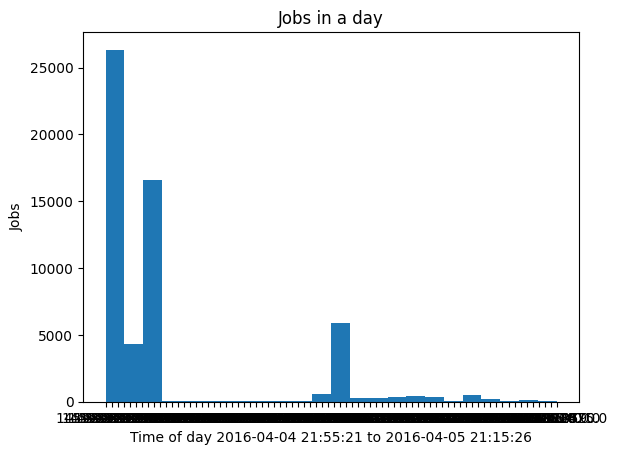

In [18]:
import matplotlib.pyplot as plt
import csv
from datetime import datetime

# This timestamp comes from exploring the data
time_of_day = 1459806921 + 3600 * 24

with open("nova_fullday_2016-04-05.nodetype.csv") as csv_file:  # Open the data file in the context
  csv_data = csv.reader(csv_file)  # Read it as CSV file
  csv_data_list = [row[1] for row in csv_data if float(row[1])<time_of_day]

# Data exploration
print(f"Number of values: {len(csv_data_list)}")

print(f"Min timestamp: {min(csv_data_list)} ({datetime.fromtimestamp(float(min(csv_data_list)))})")
print(f"Max timestamp: {max(csv_data_list)} ({datetime.fromtimestamp(float(max(csv_data_list)))})")
# 1459806921.0
# 1459923540.0

plt.hist(csv_data_list, 24)
plt.title("Jobs in a day")
plt.xlabel(f"Time of day {datetime.fromtimestamp(float(min(csv_data_list)))} to {datetime.fromtimestamp(float(max(csv_data_list)))}")
plt.ylabel("Jobs")